In [674]:
from src.config import *

In [16]:
dfCreditData = pd.read_csv('synthetic_credit_panel.csv')

In [17]:
dfCreditData 

,firm_id,year,total_assets,debt_assets,roa,current_ratio,interest_coverage,revenue_growth,volatility,pd,default,lgd,ead
0,0,2023,5.372018e+06,0.170712,0.106484,1.536870,8.346899,0.098576,0.293682,0.002000,0,0.694730,1.117247e+06
1,1,2023,2.846884e+06,0.243033,0.031237,2.001361,28.622757,-0.171364,0.353789,0.002000,0,0.406691,9.565980e+05
2,2,2023,6.247479e+06,0.168680,0.116517,1.593253,2.039239,0.171956,0.147770,0.002000,0,0.856574,1.085660e+06
3,3,2023,1.499204e+07,0.119787,0.015174,1.613292,0.685379,0.174044,0.204635,0.027965,0,0.565919,2.890181e+06
4,4,2023,2.586579e+06,0.428164,0.107201,1.147336,2.984707,0.159817,0.257479,0.028811,0,0.724388,1.400520e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,3496,2024,2.049996e+06,0.531805,-0.002318,1.936896,1.692935,0.001751,0.286422,0.102831,1,0.579847,9.394455e+05
6996,3497,2024,3.812767e+06,0.279163,-0.008120,0.643033,2.226844,0.107820,0.292180,0.132484,1,0.609401,4.967475e+05
6997,3498,2024,2.024346e+06,0.301017,0.093835,1.249438,1.833409,0.174797,0.077611,0.002800,0,0.577279,7.034063e+05
6998,3499,2024,2.502618e+06,0.215155,0.074684,1.810960,1.827601,-0.042411,0.078914,0.002800,0,0.403698,4.097357e+05


In [22]:
print(dfCreditData.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead']


In [24]:
dfCreditData.isnull().sum()

firm_id              0
year                 0
total_assets         0
debt_assets          0
roa                  0
current_ratio        0
interest_coverage    0
revenue_growth       0
volatility           0
pd                   0
default              0
lgd                  0
ead                  0
dtype: int64

In [32]:
dfCreditData.describe().T

,count,mean,std,min,25%,50%,75%,max
firm_id,7000.0,1.750000e+03,1.010435e+03,0.000000,8.750000e+02,1.750000e+03,2.625000e+03,3.500000e+03
year,7000.0,2.023500e+03,5.000357e-01,2023.000000,2.023000e+03,2.023500e+03,2.024000e+03,2.024000e+03
total_assets,7000.0,5.432598e+06,7.147033e+06,122008.167567,1.676476e+06,3.268843e+06,6.403986e+06,1.657909e+08
debt_assets,7000.0,2.860314e-01,1.573453e-01,0.050000,1.615368e-01,2.657976e-01,3.877684e-01,8.959512e-01
roa,7000.0,5.068163e-02,4.000345e-02,-0.104255,2.347010e-02,5.114683e-02,7.780387e-02,2.076932e-01
current_ratio,7000.0,1.496765e+00,4.924083e-01,0.200000,1.151949e+00,1.498806e+00,1.835588e+00,3.305675e+00
interest_coverage,7000.0,3.725201e+00,3.531405e+00,0.128268,1.598014e+00,2.722071e+00,4.546566e+00,5.000000e+01
revenue_growth,7000.0,3.894926e-02,1.003682e-01,-0.406297,-2.940023e-02,3.915145e-02,1.080421e-01,4.091625e-01
volatility,7000.0,2.508394e-01,1.001358e-01,0.050000,1.802696e-01,2.501477e-01,3.198993e-01,6.227833e-01
pd,7000.0,3.540437e-02,3.744576e-02,0.002000,2.800000e-03,2.421179e-02,5.766863e-02,2.363941e-01


In [28]:
dfCreditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   firm_id            7000 non-null   int64  
 1   year               7000 non-null   int64  
 2   total_assets       7000 non-null   float64
 3   debt_assets        7000 non-null   float64
 4   roa                7000 non-null   float64
 5   current_ratio      7000 non-null   float64
 6   interest_coverage  7000 non-null   float64
 7   revenue_growth     7000 non-null   float64
 8   volatility         7000 non-null   float64
 9   pd                 7000 non-null   float64
 10  default            7000 non-null   int64  
 11  lgd                7000 non-null   float64
 12  ead                7000 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 711.1 KB


In [38]:
dfCreditData['default'].value_counts()

default
0    6757
1     243
Name: count, dtype: int64

In [743]:
df_2023 = dfCreditData[dfCreditData['year'] == 2023].copy()

In [699]:
df_2024 = dfCreditData[dfCreditData['year'] == 2024].copy()

In [90]:
print(f"2023: {len(df_2023)} , {df_2023['default'].mean():.3%}")

2023: 3500 , 3.086%


In [92]:
print(f"2024: {len(df_2024)} , {df_2024['default'].mean():.3%}")

2024: 3500 , 3.857%


In [102]:
features = ['total_assets', 'debt_assets', 'roa', 'current_ratio', 
            'interest_coverage', 'revenue_growth', 'volatility']

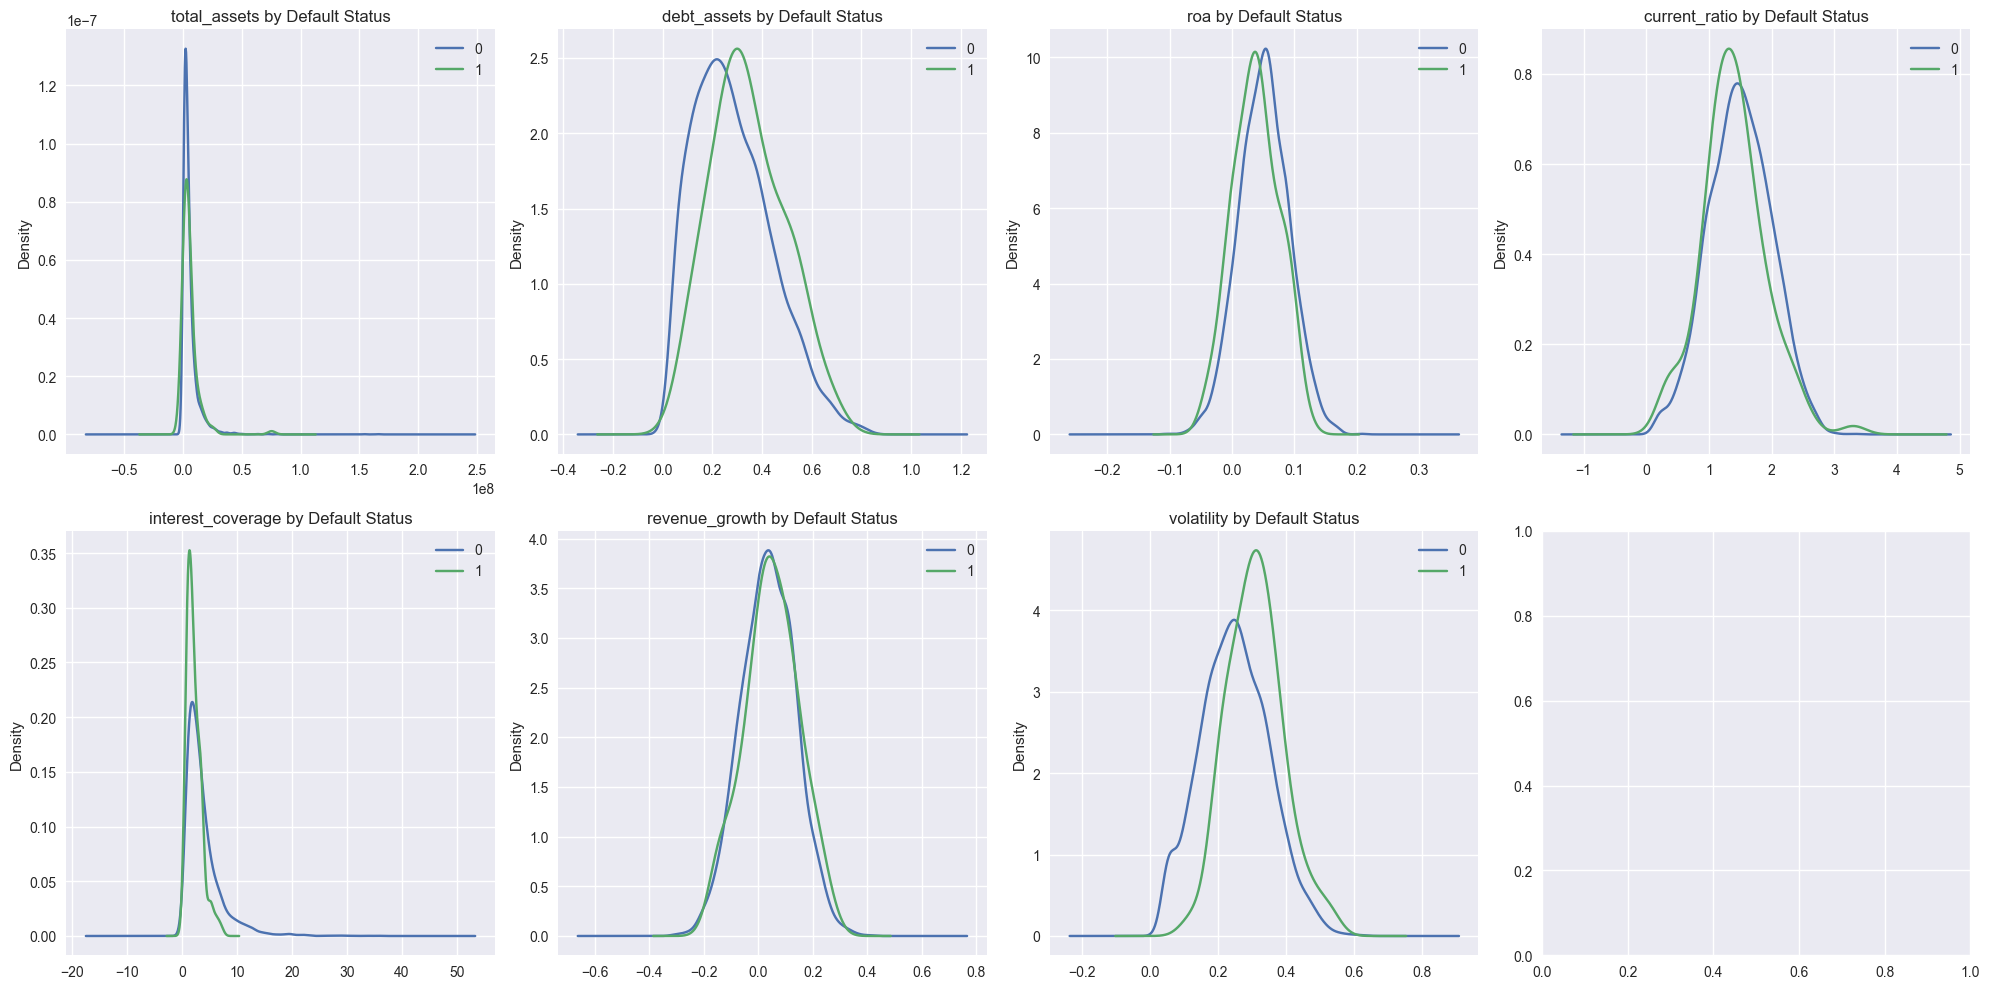

In [106]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature in enumerate(features):
    row, col = i // 4, i % 4
    df_2023.groupby('default')[feature].plot(kind='kde', ax=axes[row, col], legend=True)
    axes[row, col].set_title(f'{feature} by Default Status')
plt.tight_layout()
plt.show()

In [747]:
features_original_2023 = ['total_assets', 'debt_assets', 'roa', 'current_ratio', 
            'interest_coverage', 'revenue_growth', 'volatility']

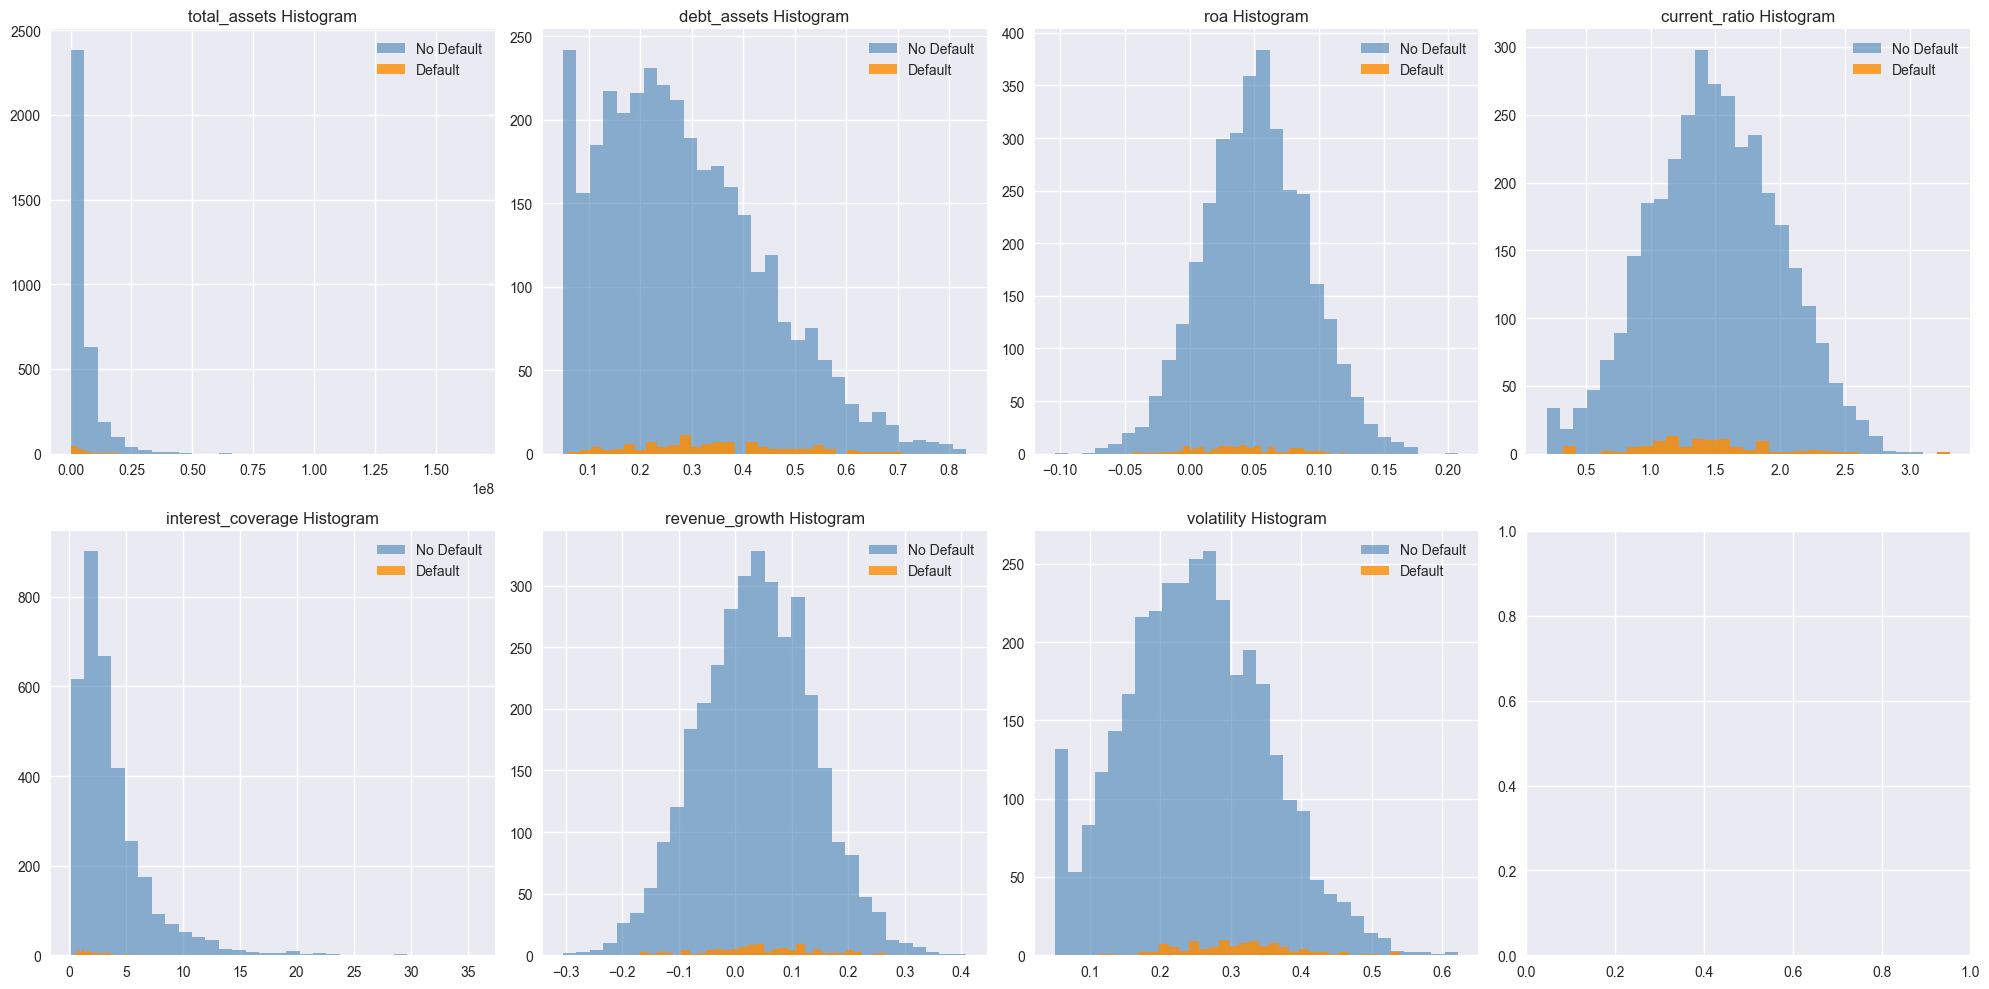

In [749]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature_2023 in enumerate(features_original_2023):
    if feature not in df_2023.columns:
        continue

    row, col = divmod(i, 4)
    ax = axes[row, col]

    df_2023[df_2023['default'] == 0][feature_2023].hist(
        ax=ax, alpha=0.6, bins=30, label='No Default', color='steelblue'
    )
    df_2023[df_2023['default'] == 1][feature_2023].hist(
        ax=ax, alpha=0.8, bins=30, label='Default',color='darkorange'
    )

    ax.set_title(f'{feature_2023} Histogram')
    ax.legend()

plt.tight_layout()
plt.show()

In [157]:
#for feature in features:
#    if feature not in df_2023.columns:
#        continue

#    g = sns.FacetGrid(df_2023, col="default", height=4, aspect=1.2)
#    g.map(sns.histplot, feature, kde=True)
 #   g.fig.suptitle(f"{feature} Distribution by Default", y=1.05)
  #  plt.show()

In [127]:
comparison_results = []

for feature in features:
    default_0 = df_2023[df_2023['default'] == 0][feature].dropna()
    default_1 = df_2023[df_2023['default'] == 1][feature].dropna()
    
  
    t_stat, p_value = stats.ttest_ind(default_0, default_1, equal_var=False)

    d0_mean = default_0.mean()
    d1_mean = default_1.mean()
    difference = d0_mean - d1_mean

    pooled_std = np.sqrt((default_0.std()**2 + default_1.std()**2) / 2)
    cohens_d = difference / pooled_std if pooled_std != 0 else 0

    if p_value < 0.001:
        significant = '***'
    elif p_value < 0.01:
        significant = '**'
    elif p_value < 0.05:
        significant = '*'
    else:
        significant = ''
    
    comparison_results.append({
        'Feature': feature,
        'Default_0 Mean': d0_mean,
        'Default_1 Mean': d1_mean,
        'Difference': difference,
        'T-Statistic': t_stat,
        'P-Value': p_value,
        'Effect_Size_Cohens_d': cohens_d,
        'd0_Sample_Size': len(default_0),
        'd1_Sample_Size': len(default_1),
        'Significant': significant
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('P-Value')

In [131]:
print(comparison_df[['Feature', 'Default_0 Mean', 'Default_1 Mean', 'Difference', 'T-Statistic',
                     'P-Value', 'Effect_Size_Cohens_d', 'Significant']].round(4))

             Feature  Default_0 Mean  Default_1 Mean   Difference  \
4  interest_coverage    3.752100e+00    2.147100e+00       1.6050   
6         volatility    2.495000e-01    3.106000e-01      -0.0611   
1        debt_assets    2.835000e-01    3.438000e-01      -0.0603   
2                roa    5.120000e-02    3.820000e-02       0.0130   
3      current_ratio    1.495100e+00    1.396300e+00       0.0988   
5     revenue_growth    3.710000e-02    4.870000e-02      -0.0115   
0       total_assets    5.521622e+06    5.644533e+06 -122910.8332   

   T-Statistic  P-Value  Effect_Size_Cohens_d Significant  
4      11.4633   0.0000                0.6312         ***  
6      -7.5683   0.0000               -0.6679         ***  
1      -4.1806   0.0001               -0.3972         ***  
2       3.6304   0.0004                0.3397         ***  
3       1.9967   0.0483                0.1966           *  
5      -1.1862   0.2380               -0.1155              
0      -0.1504   0.8807    

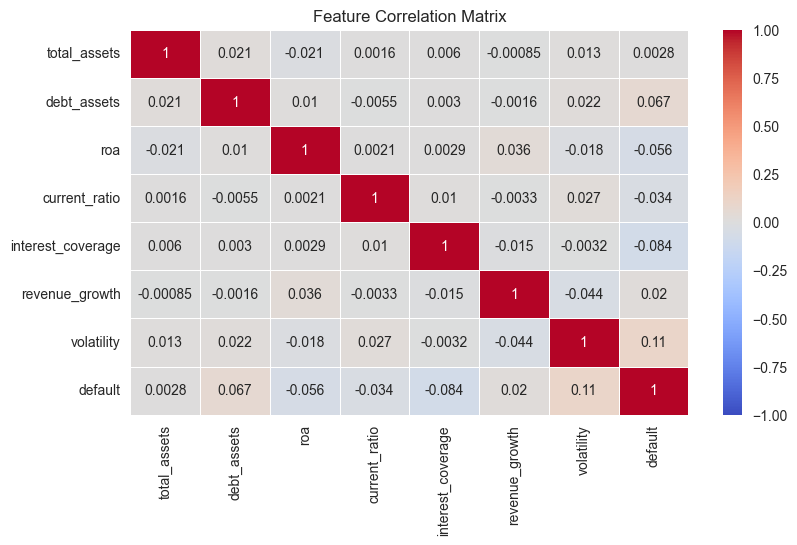

In [244]:
plt.figure(figsize=(9, 5))
corr_matrix = df_2023[features + ['default']].corr()
sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm',
        #cmap="RdBu_r",     
        vmin=-1, vmax=1,     
        linewidths=0.5,      
        ##linecolor='lightgray',
        cbar=True,
        center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [159]:
X_train = df_2023[features]
y_train = df_2023['default']
X_test = df_2024[features]
y_test = df_2024['default']

In [161]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [214]:
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    #'class_weight': [None, 'balanced']
}

In [216]:
base_model = LogisticRegression(
    max_iter = 1000, 
    random_state = 42,
    penalty = 'l2',
    solver = 'lbfgs'
)


In [218]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [220]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [222]:
grid_search = GridSearchCV(
            base_model,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )     

In [224]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc')

In [225]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

In [226]:
top_results = results_df[['param_C', 
                            'mean_train_score', 'mean_test_score', 
                            'std_test_score']].head(5)

In [227]:
top_results.columns = ['C', 'Train_AUC', 'CV_AUC', 'CV_Std']

In [232]:
print(top_results.to_string(index=False))

    C  Train_AUC   CV_AUC   CV_Std
 1.00   0.794716 0.777159 0.024894
10.00   0.794521 0.776883 0.025340
 5.00   0.794539 0.776870 0.025331
 0.10   0.794158 0.776684 0.022580
 0.01   0.786660 0.770762 0.025595


In [234]:
lr_model = grid_search.best_estimator_

In [238]:
test_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"CV AUC: {grid_search.best_score_:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Best parameters: {'C': 1}
CV AUC: 0.7772
Test AUC: 0.7719


In [246]:
df_2023['debt_assets_roa'] = df_2023['debt_assets'] * df_2023['roa']
df_2024['debt_assets_roa'] = df_2024['debt_assets'] * df_2024['roa']

In [248]:
features.append('debt_assets_roa')  

In [250]:
def plot_pd_vs_deciles(df, features, target='default', q=10):
    for feature in features:
        try:
           
            df['_decile'] = pd.qcut(df[feature], q=q, duplicates='drop')
            
           
            pd_profile = df.groupby('_decile', observed=True)[target].agg(['mean', 'count']).reset_index()
            pd_profile = pd_profile.sort_values('_decile').reset_index(drop=True)
            
           
            plt.figure(figsize=(8, 5))
            x_positions = range(len(pd_profile))
            plt.plot(x_positions, pd_profile['mean'], marker='o', linewidth=2, markersize=8)
            
          
            for i, (x, y, n) in enumerate(zip(x_positions, pd_profile['mean'], pd_profile['count'])):
                plt.text(x, y, f'n={n}', fontsize=8, ha='center', va='bottom')
            
            plt.title(f'PD vs {feature} (Quantile Bins)', fontsize=12, fontweight='bold')
            plt.xlabel(f'{feature} bins', fontsize=10)
            plt.ylabel('Observed PD', fontsize=10)
            plt.xticks(x_positions, [f'Q{i+1}' for i in x_positions], rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            
            df.drop('_decile', axis=1, inplace=True)
            
        except Exception as e:
            print(f"Skipping feature {feature}: {str(e)}")
            if '_decile' in df.columns:
                df.drop('_decile', axis=1, inplace=True)

# zip: combine three lists, and creates tuples pairing elements from each list
# enumerate: add index i
# ha: horizontal alignment
# va: vertical alignment

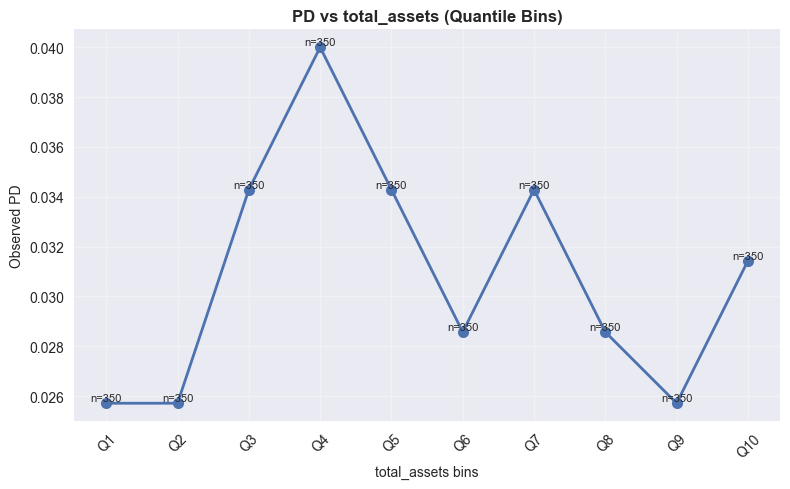

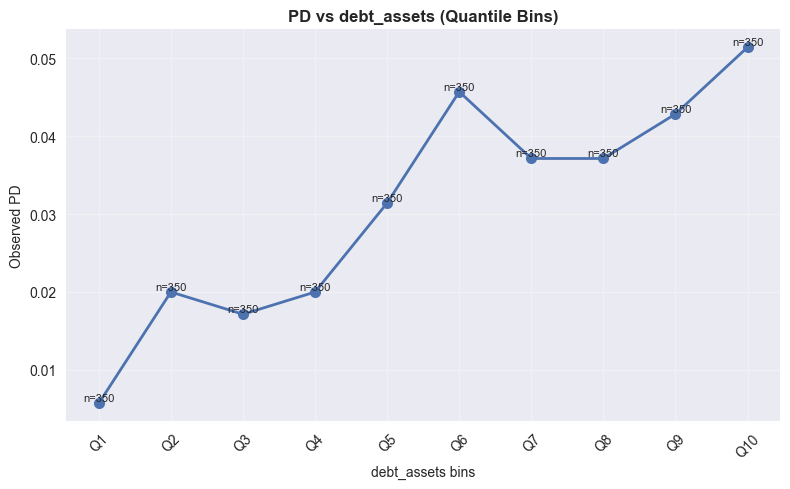

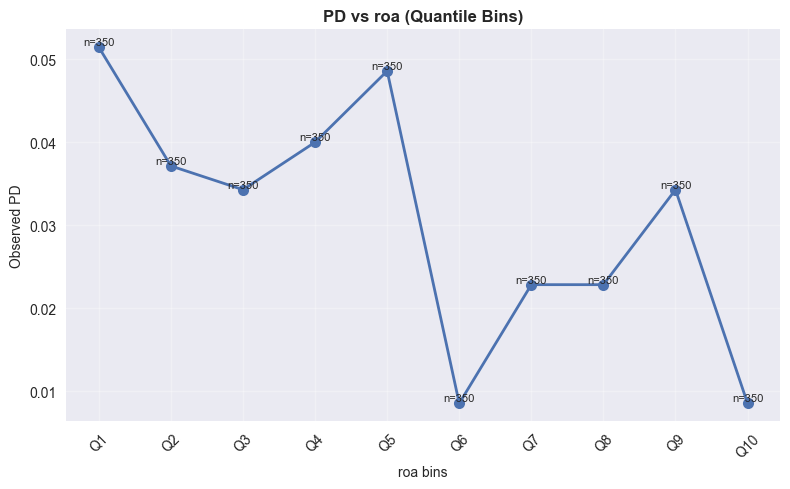

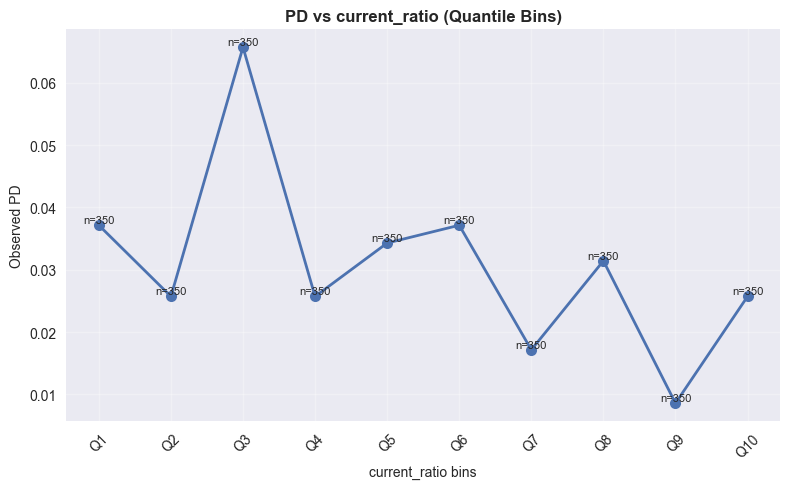

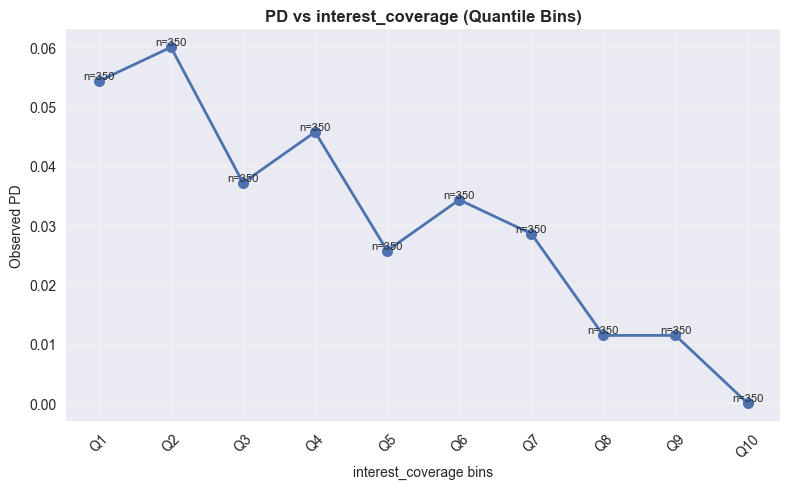

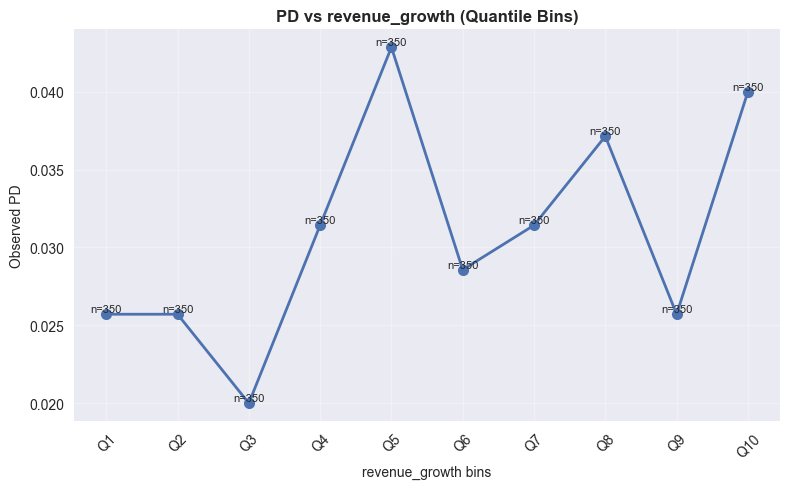

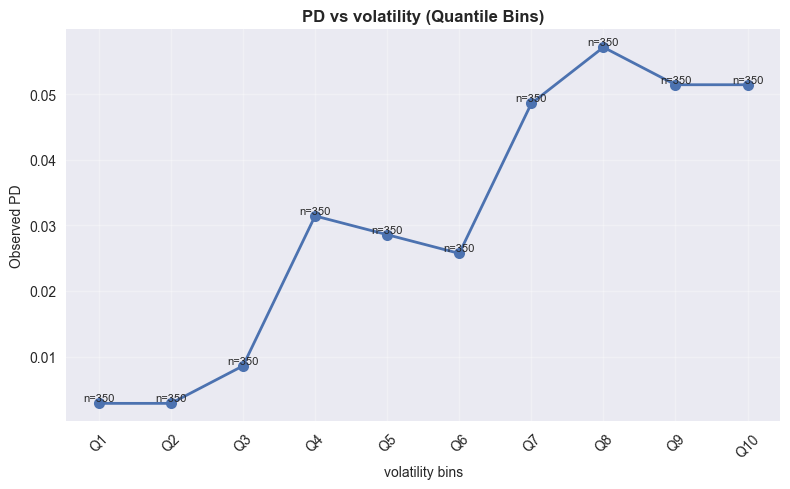

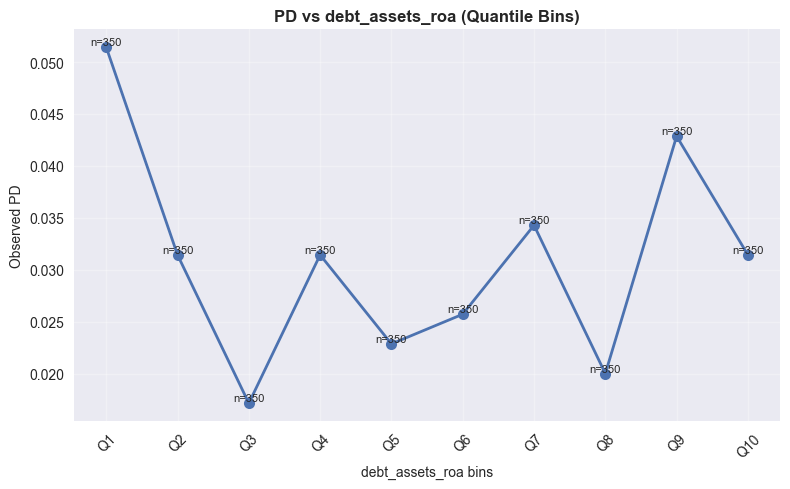

In [252]:
plot_pd_vs_deciles(df_2023, features=features)

In [47]:
def woe_iv(data, feature, target='default', q=10):
    
    df = data.copy()
    
   
    df['_bin'] = pd.qcut(df[feature], q=q, duplicates='drop')
    
  
    grouped = df.groupby('_bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'defaults']
    grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
    grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
    total_defaults = grouped['defaults'].sum()
    total_non_defaults = grouped['non_defaults'].sum()
    
   
    grouped['dist_default'] = grouped['defaults'] / total_defaults
    grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
    epsilon = 1e-10
    grouped['WoE'] = np.log(
        (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
    )
    
  
    grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
    grouped = grouped.sort_index()
    total_iv = grouped['IV'].sum()
    
   
    woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
    return woe_table, total_iv


# high default bin : positive WoE

In [49]:
def woe_iv_report(data, features, target='default', q=10):
    report = {}
    for feature in features:
        woe_table, iv = woe_iv(data, feature, target, q)
        report[feature] = {'IV': iv, 'WoE': woe_table}
        print(f"{feature:20} IV = {iv:.4f}")
        print(woe_table.round(4))
    return report

In [51]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', q=10)

total_assets         IV = 0.0229
                                  total  defaults  non_defaults  default_rate  \
_bin                                                                            
(127865.30099999999, 942279.903]    350         9           341        0.0257   
(942279.903, 1444153.275]           350         9           341        0.0257   
(1444153.275, 1963286.475]          350        12           338        0.0343   
(1963286.475, 2598255.879]          350        14           336        0.0400   
(2598255.879, 3338852.417]          350        12           338        0.0343   
(3338852.417, 4322741.968]          350        10           340        0.0286   
(4322741.968, 5593669.3]            350        12           338        0.0343   
(5593669.3, 7646251.279]            350        10           340        0.0286   
(7646251.279, 12177916.336]         350         9           341        0.0257   
(12177916.336, 165790865.628]       350        11           339        0.031

In [ ]:
# for features: 'total_assets', 'roa', 'current_ratio', 'revenue_growth',
# the increases lead to the decrease of PD, therefore WoE should decrease
# stop condition: WoE is monotonic
# safety conditions: maximum iterations, minimum # of bins
# merge criteria: violation of monotonicity, smallest chi-square
# all calculations and merging are based on dataframe woe_table

In [245]:
def chimerge_monotonic(data, feature, target='default',
                       initial_bins=30,
                       min_bins=3,
                       max_iterations=50,
                       direction='decreasing'):
    
    df = data.copy()

    df['_bin'] = pd.qcut(df[feature], q=initial_bins, duplicates='drop')
    df['_bin'] = df['_bin'].astype(object) 

    def calculate_woe_from_bins(df):
   
   
        grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
        grouped.columns = ['total', 'defaults']
        grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
        grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
        total_defaults = grouped['defaults'].sum()
        total_non_defaults = grouped['non_defaults'].sum()

        if total_defaults == 0 or total_non_defaults == 0:
            return None, None
    
   
        grouped['dist_default'] = grouped['defaults'] / total_defaults
        grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
        epsilon = 1e-10
        grouped['WoE'] = np.log(
            (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
        )
    
  
        grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
        grouped = grouped.sort_index()
        total_iv = grouped['IV'].sum()
    
   
        woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
        return woe_table, total_iv

    def check_monotonicity(woe_values):
        woe_values = np.array(woe_values)
         
        if len(woe_values) < 2:
            return True
            
        diffs = np.diff(woe_values)
        
        return np.all(diffs >= -1e-6) or np.all(diffs <= 1e-6)

    def calculate_chi_square(bin1_counts, bin2_counts):
         
        a, b = bin1_counts
        c, d = bin2_counts
        observed = np.array([[a, c], [b, d]])
        
        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0

    woe_table, total_iv = calculate_woe_from_bins(df)
    if woe_table is None:
        return None, None, None
    
    print(f"Initial IV: {total_iv:.4f}")

    iteration = 0
    
    while iteration < max_iterations:
        
       

        woe_table, total_iv = calculate_woe_from_bins(df)
        woe_values = woe_table['WoE'].values
        is_monotonic = check_monotonicity(woe_values)

        current_bins = woe_table.index.tolist()
        n_bins = len(current_bins)

        if n_bins <= min_bins:
        
            if is_monotonic:
                print("Reached minimum bins - monotonic WoE")
            
            else:
                print("Reached minimum bins - WoE NOT monotonic!")
           
            break

        if is_monotonic:
            
            print("Achieved monotonic WoE")
            
            break

        if direction == 'decreasing':
            overall_direction = -1
            
        elif direction == 'increasing':
            overall_direction = 1

        else:
            raise ValueError("direction must be 'increasing', or 'decreasing'")
        

        chi_squares = []
        violations = []
        
        for i in range(len(current_bins) - 1):
            bin1 = current_bins[i]
            bin2 = current_bins[i + 1]

            bin1_defaults = woe_table.loc[bin1, 'defaults']
            bin1_non_defaults = woe_table.loc[bin1, 'non_defaults']
            bin2_defaults = woe_table.loc[bin2, 'defaults']
            bin2_non_defaults = woe_table.loc[bin2, 'non_defaults']
       
            chi2_stat = calculate_chi_square(
                (bin1_non_defaults, bin1_defaults),
                (bin2_non_defaults, bin2_defaults)
            )
            
            chi_squares.append((i, chi2_stat, bin1, bin2))

            woe1 = woe_table.loc[bin1, 'WoE']
            woe2 = woe_table.loc[bin2, 'WoE']
            diff = woe2 - woe1

            if overall_direction * diff < -1e-6:
                violations.append((i, chi2_stat, bin1, bin2))
        
        if not chi_squares:
            break
            
        if violations:
            merge_candidate = min(violations, key=lambda x: x[1])
            print("Merging violation")
        else:
            merge_candidate = min(chi_squares, key=lambda x: x[1])
            print("Merging smallest chi square")

        merge_idx, chi2_val, bin1, bin2 = merge_candidate
        new_left = min(bin1.left, bin2.left)
        new_right = max(bin1.right, bin2.right)
        merged_bin = pd.Interval(new_left, new_right, closed='right')
        
        df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
        df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
                
        iteration += 1


    if iteration == max_iterations:
        print("Reached maximum iterations")
        print("WoE may not be monotonic!")
    

    
    woe_table, total_iv = calculate_woe_from_bins(df)
    woe_values = woe_table['WoE'].values
    is_monotonic = check_monotonicity(woe_values)

  
    final_bins = sorted(df['_bin'].unique(), key=lambda x: x.left)
    bin_edges = [final_bins[0].left] + [b.right for b in final_bins]
    
    return woe_table, total_iv, bin_edges

    
   
   
   
    

In [248]:
def woe_iv_report(data, features, target='default',
                    initial_bins=30,
                    min_bins=3,
                    max_iterations=50,
                    direction='decreasing'):
    
    report = {}
    for feature in features:
        woe_table, total_iv, edges = chimerge_monotonic(data, feature, target, initial_bins, min_bins, max_iterations, direction)
        report[feature] = {'IV': total_iv, 'WoE': woe_table, 'bin_edge': edges}

        print(f"Final bins: {len(woe_table)}")
        print(f"{feature:20} IV = {total_iv:.4f}")
        print(woe_table.round(4))
    return report

In [250]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.8277
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0041
                                   total  defaults  non_defaults  \
_bin                                                               
(127865.30099999999, 3637162.564]   1867        60          1807   
(3637162.564, 6111390.727]           699        22           677   
(6111390.727, 20794009.04]           817        23           794   
(20794009.04, 165790865.628]         117         3           114   

                                  

In [264]:
def plot_linearity(report, feature):
    table = report[feature]['WoE']
    eps = 1e-7
    df_rate = table['default_rate'].clip(eps, 1-eps)
    log_odds = np.log(df_rate / (1 - df_rate))

    plt.scatter(table['WoE'], log_odds)
    plt.xlabel("WoE")
    plt.ylabel("log-odds")
    plt.title(f"Linearity Check: {feature}")
    plt.grid(True)
    plt.show()

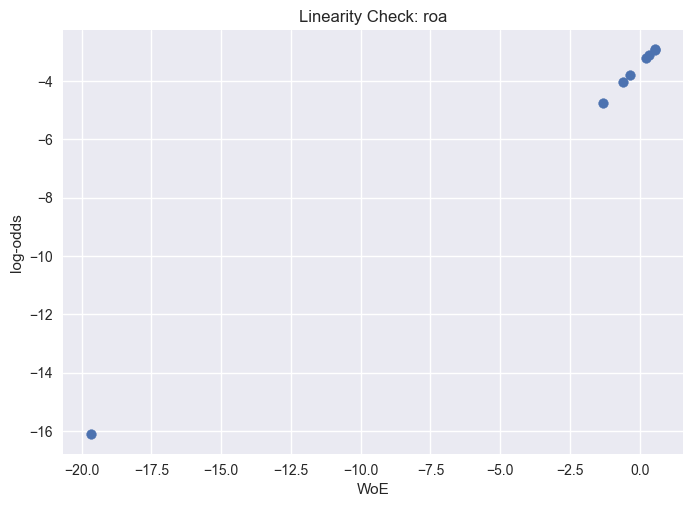

In [266]:
plot_linearity(report, 'roa')


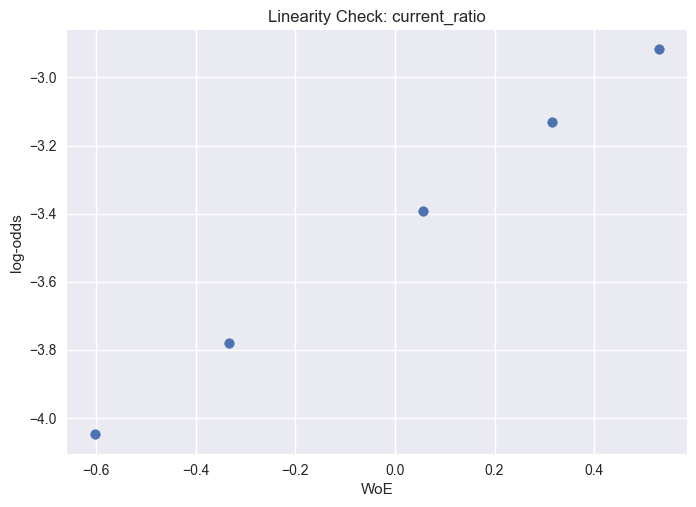

In [268]:
plot_linearity(report, 'current_ratio')

In [377]:
def chimerge_monotonic(data, feature, target='default',
                       initial_bins=30,
                       min_bins=3,
                       max_iterations=50,
                       direction='decreasing'):
    
    df = data.copy()

    df['_bin'] = pd.qcut(df[feature], q=initial_bins, duplicates='drop')
    df['_bin'] = df['_bin'].astype(object) 

    def calculate_woe_from_bins(df):
   
   
        grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
        grouped.columns = ['total', 'defaults']
        grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
        grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
        total_defaults = grouped['defaults'].sum()
        total_non_defaults = grouped['non_defaults'].sum()

        if total_defaults == 0 or total_non_defaults == 0:
            return None, None
    
   
        grouped['dist_default'] = grouped['defaults'] / total_defaults
        grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
        epsilon = 1e-10
        grouped['WoE'] = np.log(
            (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
        )
    
  
        grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
        grouped = grouped.sort_index()
        total_iv = grouped['IV'].sum()
    
   
        woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
        return woe_table, total_iv

    def check_monotonicity(woe_values):
        woe_values = np.array(woe_values)
         
        if len(woe_values) < 2:
            return True
            
        diffs = np.diff(woe_values)
        
        return np.all(diffs >= -1e-6) or np.all(diffs <= 1e-6)

    def calculate_chi_square(bin1_counts, bin2_counts):
         
        a, b = bin1_counts
        c, d = bin2_counts
        observed = np.array([[a, c], [b, d]])
        
        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0

    woe_table, total_iv = calculate_woe_from_bins(df)
    if woe_table is None:
        return None, None, None
    
    print(f"Initial IV: {total_iv:.4f}")

    iteration = 0
    
    while iteration < max_iterations:
        
       

        woe_table, total_iv = calculate_woe_from_bins(df)
        woe_values = woe_table['WoE'].values
        is_monotonic = check_monotonicity(woe_values)

        current_bins = list(woe_table.index)
        n_bins = len(current_bins)

        if n_bins <= min_bins:
        
            if is_monotonic:
                print("Reached minimum bins - monotonic WoE")
            
            else:
                print("Reached minimum bins - WoE NOT monotonic!")
           
            break

        if is_monotonic:
            
            print("Achieved monotonic WoE")
            
            break

        
        overall_direction = -1 if direction == 'decreasing' else 1
            
        
        chi_squares = []
        violations = []
        
        for i in range(n_bins - 1):
            bin1 = current_bins[i]
            bin2 = current_bins[i + 1]

            bin1_defaults = woe_table.loc[bin1, 'defaults']
            bin1_non_defaults = woe_table.loc[bin1, 'non_defaults']
            bin2_defaults = woe_table.loc[bin2, 'defaults']
            bin2_non_defaults = woe_table.loc[bin2, 'non_defaults']
       
            chi2_stat = calculate_chi_square(
                (bin1_non_defaults, bin1_defaults),
                (bin2_non_defaults, bin2_defaults)
            )
            
            chi_squares.append((i, chi2_stat, bin1, bin2))

            woe1 = woe_table.loc[bin1, 'WoE']
            woe2 = woe_table.loc[bin2, 'WoE']
            diff = woe2 - woe1

            if overall_direction * diff < -1e-6:
                violations.append((i, chi2_stat, bin1, bin2))
        
        if not chi_squares:
            break
            
        if violations:
            merge_candidate = min(violations, key=lambda x: x[1])
            print("Merging violation")
        else:
            merge_candidate = min(chi_squares, key=lambda x: x[1])
            print("Merging smallest chi square")

        merge_idx, chi2_val, bin1, bin2 = merge_candidate
        new_left = min(bin1.left, bin2.left)
        new_right = max(bin1.right, bin2.right)
        merged_bin = pd.Interval(new_left, new_right, closed='right')
        
        df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
        df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
                
        iteration += 1


    if iteration == max_iterations:
        print("Reached maximum iterations")
        print("WoE may not be monotonic!")
    

    
    woe_table, total_iv = calculate_woe_from_bins(df)
    woe_values = woe_table['WoE'].values
    is_monotonic = check_monotonicity(woe_values)

  
    final_bins = sorted(df['_bin'].unique(), key=lambda x: x.left)
    bin_edges = [-np.inf] + [b.right for b in final_bins[:-1]] + [+np.inf]
    
    return woe_table, total_iv, bin_edges

    
   
   
   
    

In [383]:
def woe_iv_report(data, features, target='default',
                    initial_bins=30,
                    min_bins=3,
                    max_iterations=50,
                    direction='decreasing'):
    
    report = {}
    for feature in features:
        woe_table, total_iv, edges = chimerge_monotonic(
            data, feature, target, 
            initial_bins, min_bins, 
            max_iterations, direction
        )
        report[feature] = {
            'IV': total_iv, 
            'WoE': woe_table, 
            'bin_edge': edges
        }

        print(f"Final bins: {len(woe_table)}")
        print(f"{feature:20} IV = {total_iv:.4f}")
        print(woe_table[['WoE', 'IV']])
    return report

In [385]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.8277
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0041
                                        WoE        IV
_bin                                                 
(127865.30099999999, 3637162.564]  0.041965  0.000958
(3637162.564, 6111390.727]         0.020415  0.000084
(6111390.727, 20794009.04]        -0.094545  0.001997
(20794009.04, 165790865.628]      -0.190542  0.001111
Initial IV: 1.7512
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging vi

In [405]:
class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, woe_report):
        self.woe_report = woe_report
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_transformed = X.copy()
        for feature in self.woe_report.keys():
            if feature in X.columns:
                woe_table = self.woe_report[feature]['WoE']
                #bin_edges = self.woe_report[feature]['bin_edge']
                
                
                woe_values = woe_table['WoE'].values
                bin_labels = woe_table.index

                woe_map = dict(zip(bin_labels, woe_values))

                bins = pd.cut(X[feature], bins=bin_labels)
             
                
                X_transformed[feature + '_woe'] = bins.map(woe_map)

                #fallback = woe_values.mean()
                #X_transformed[feature + '_woe'].fillna(fallback, inplace=True)
    
                    
        return X_transformed

    def get_params(self, deep=True):
        return {"woe_report": self.woe_report}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [407]:
woe_features = ['roa', 'current_ratio']
original_features = ['debt_assets', 'interest_coverage', 'volatility']

In [409]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features),
        ('scaler', StandardScaler(), original_features)
    ],
    remainder='drop' 
)

In [433]:
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42, 
        max_iter=1000,
        penalty = 'l2',
        solver = 'lbfgs',
        class_weight='balanced'
    ))
])

In [375]:
#tmp = WoETransformer(report).fit_transform(X[woe_features])
#tmp.isna().sum()

In [435]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    
}

In [437]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [439]:
grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=2,
            return_train_score=True
        )   

In [441]:
X = df_2023[woe_features + original_features]
y = df_2023['default']


In [443]:
grid_search.fit(X, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('woe',
                                                                         WoETransformer(woe_report={'current_ratio': {'IV': 0.11496387616108558,
                                                                                                                      'WoE':                 total  defaults  non_defaults  default_rate  dist_default  \
_bin                                                                        
(0.199, 0.573]    117         6           111      0.051282      0.055556   
(0.573, 1.228]    933        39           894      0.041801      0....
                                                                                                                     'bin_edge': [-inf,
                                                                                                                                  3637162.564,
                                                                                                                                  6111390.727,
                                                                                                                                  20794009.04,
                                                                                                                                  inf]}}),
                                                                         ['roa',
                                                                          'current_ratio']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['debt_assets',
                                                                          'interest_coverage',
                                                                          'volatility'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [444]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")


Best Parameters: {'classifier__C': 5}
Best Cross-Validation ROC-AUC Score: 0.8062


In [447]:
best_model = grid_search.best_estimator_

In [449]:
y_pred = best_model.predict(X)
y_pred_proba = best_model.predict_proba(X)[:, 1]

In [451]:
print("\nClassification Report:")
print(classification_report(y, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      3392
           1       0.07      0.76      0.14       108

    accuracy                           0.70      3500
   macro avg       0.53      0.73      0.48      3500
weighted avg       0.96      0.70      0.80      3500



In [453]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y, y_pred_proba):.4f}")



Confusion Matrix:
[[2379 1013]
 [  26   82]]

ROC-AUC Score: 0.8183


In [455]:
precision, recall, thresholds = precision_recall_curve(y, y_pred_proba)

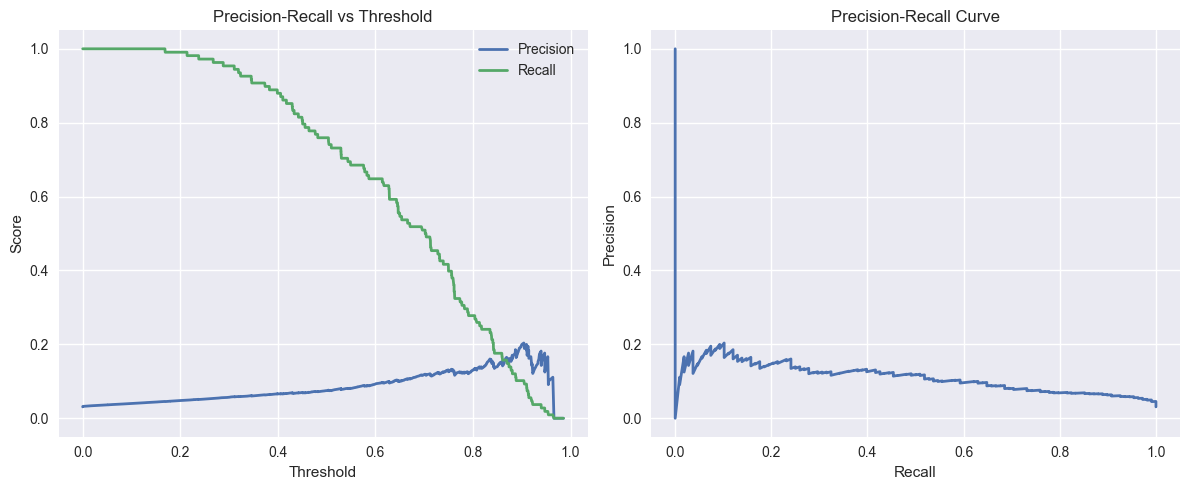

In [465]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


In [467]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold_f1= thresholds[optimal_idx]

print(f"Optimal threshold(F1): {optimal_threshold_f1:.4f}")

Optimal threshold(F1): 0.7494


In [469]:
y_pred_optimal = (y_pred_proba >= optimal_threshold_f1).astype(int)

In [471]:
print(classification_report(y, y_pred_optimal))
print(f"Confusion Matrix:\n{confusion_matrix(y, y_pred_optimal)}")

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      3392
           1       0.13      0.42      0.20       108

    accuracy                           0.90      3500
   macro avg       0.56      0.66      0.57      3500
weighted avg       0.95      0.90      0.92      3500

Confusion Matrix:
[[3093  299]
 [  63   45]]


In [493]:
threshold_setting = 0.56  

y_pred_customized = (y_pred_proba >= threshold_setting).astype(int)

print(classification_report(y, y_pred_customized))
print(confusion_matrix(y, y_pred_customized))

              precision    recall  f1-score   support

           0       0.99      0.76      0.86      3392
           1       0.08      0.69      0.15       108

    accuracy                           0.76      3500
   macro avg       0.54      0.72      0.50      3500
weighted avg       0.96      0.76      0.84      3500

[[2582  810]
 [  34   74]]


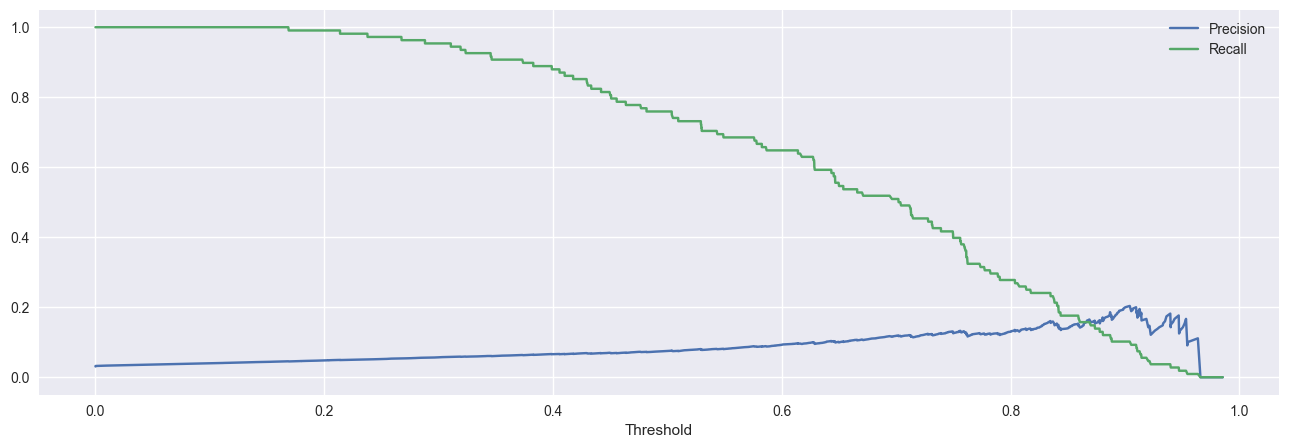

In [495]:
precision, recall, threshold_setting = precision_recall_curve(y, y_pred_proba)


plt.figure(figsize=(16, 5))
plt.plot(threshold_setting, precision[:-1], label="Precision")
plt.plot(threshold_setting, recall[:-1], label="Recall")
plt.legend()
plt.xlabel("Threshold")
plt.show()

In [ ]:
# it is crucial to have higher recall
# The F1-maximizing approach failed here 
# because it doesn't account for the asymmetric costs of different error types in credit risk

In [ ]:
# grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
# woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
 #                        'dist_default', 'dist_non_default', 'WoE', 'IV']]

# report[feature] = {'IV': total_iv, 'WoE': woe_table, 'bin_edge': edges}
# grouped is dataframe with index, and its type (grouped.index) is Interval Index. 
# so woe_table is also dataframe with index, Interval Index type.
# bin_edges is the list of numeric values (floats).
# grouped.index: IntervalIndex object
# woe_table.index: IntervalIndex object
# bin_labels (dictionary key): IntervalIndex object
# type of bin_labels: InvervalIndex
# bins from pd.cut(): series with categoricalDtype, contains Interval objects
# bins = pd.cut(X[feature], bins=bin_edges, include_lowest=True)
# assign original data of features (each observation) to a bin based on bin_edges

In [ ]:
# woe_map = woe_table['WoE'].to_dict()  creating a dictionary mapping 

In [508]:
class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, woe_report):
        self.woe_report = woe_report
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_transformed = X.copy()
        cols_to_drop = []
        
        for feature in self.woe_report.keys():
            if feature in X.columns:
                woe_table = self.woe_report[feature]['WoE']
                #bin_edges = self.woe_report[feature]['bin_edge']
                
                
                woe_values = woe_table['WoE'].values
                bin_labels = woe_table.index

                woe_map = dict(zip(bin_labels, woe_values))

                bins = pd.cut(X[feature], bins=bin_labels)
             
                
                X_transformed[feature + '_woe'] = bins.map(woe_map)
                
                cols_to_drop.append(feature)
                

                #fallback = woe_values.mean()
                #X_transformed[feature + '_woe'].fillna(fallback, inplace=True)

        X_transformed = X_transformed.drop(columns=cols_to_drop)
                    
        return X_transformed

    def get_params(self, deep=True):
        return {"woe_report": self.woe_report}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [510]:
woe_features = ['roa', 'current_ratio']
original_features = ['debt_assets', 'interest_coverage', 'volatility']

In [512]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features),
        ('scaler', StandardScaler(), original_features)
    ],
    remainder='drop' 
)

In [514]:
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42, 
        max_iter=1000,
        penalty = 'l2',
        solver = 'lbfgs',
        class_weight='balanced'
    ))
])

In [516]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    
}

In [518]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [520]:
grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=2,
            return_train_score=True
        )  

In [522]:
X = df_2023[woe_features + original_features]
y = df_2023['default']

In [524]:
grid_search.fit(X, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('woe',
                                                                         WoETransformer(woe_report={'current_ratio': {'IV': 0.11496387616108558,
                                                                                                                      'WoE':                 total  defaults  non_defaults  default_rate  dist_default  \
_bin                                                                        
(0.199, 0.573]    117         6           111      0.051282      0.055556   
(0.573, 1.228]    933        39           894      0.041801      0....
                                                                                                                     'bin_edge': [-inf,
                                                                                                                                  3637162.564,
                                                                                                                                  6111390.727,
                                                                                                                                  20794009.04,
                                                                                                                                  inf]}}),
                                                                         ['roa',
                                                                          'current_ratio']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['debt_assets',
                                                                          'interest_coverage',
                                                                          'volatility'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [525]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")


Best Parameters: {'classifier__C': 1}
Best Cross-Validation ROC-AUC Score: 0.7969


In [528]:
best_model = grid_search.best_estimator_

In [530]:
y_pred = best_model.predict(X)
y_pred_proba = best_model.predict_proba(X)[:, 1]

In [532]:
print("\nClassification Report:")
print(classification_report(y, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      3392
           1       0.07      0.74      0.13       108

    accuracy                           0.69      3500
   macro avg       0.53      0.71      0.47      3500
weighted avg       0.96      0.69      0.79      3500



In [534]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y, y_pred_proba):.4f}")


Confusion Matrix:
[[2333 1059]
 [  28   80]]

ROC-AUC Score: 0.8060


In [564]:
best_model = grid_search.best_estimator_

In [536]:
def extract_feature_coeff(model, feature_names):
    Lg_model = model.named_steps['classifier']
    coefficients = Lg_model.coef_[0]
    intercept = Lg_model.intercept_[0]

    coef_df = pd.DataFrame({
        'Feature': feature_names + ['Intercept'],
        'Coefficient': np.append(coefficients, intercept),
        
    })
    return coef_df
    

In [538]:
feature_names = ['roa_woe', 'current_ratio_woe', 'debt_assets', 'interest_coverage', 'volatility']

In [540]:
coef_df = extract_feature_coeff(best_model, feature_names)

In [542]:
print(coef_df.to_string(index=False))

          Feature  Coefficient
          roa_woe     1.096936
current_ratio_woe     1.080471
      debt_assets     0.518344
interest_coverage    -1.430244
       volatility     0.786085
        Intercept    -0.768393


In [576]:
from sklearn.utils import resample
from sklearn.base import clone

In [594]:
def bootstrap_coeff(X, y, model, n_boot= 100, random_state=42):

    bootstrap_coeffs = []
    bootstrap_AUC = []

    for i in range(n_boot):
        X_boot,y_boot = resample(
            X, y,
            replace = True,
            n_samples = len(X),
            random_state = random_state + i,
            stratify = y
        )

        model_boot = clone(model)
        model_boot.fit(X_boot, y_boot)

        Lg_model = model_boot.named_steps['classifier']
        coefficients = Lg_model.coef_[0]
        intercept = Lg_model.intercept_[0]

        bootstrap_coeffs.append(np.append(coefficients, intercept))
        


        y_pred_proba = model_boot.predict_proba(X_boot)[:, 1]
        AUC = roc_auc_score(y_boot, y_pred_proba)
        bootstrap_AUC.append(AUC)

    bootstrap_coeffs = np.array(bootstrap_coeffs)
    bootstrap_AUC = np.array(bootstrap_AUC)
           

    return bootstrap_coeffs, bootstrap_AUC
        

In [560]:
# bootstrap_coeffs shape: n_boot, n features, axis = 0: across all bootstrap samples for a fixed feature


In [596]:
bootstrap_coeffs, bootstrap_AUC = bootstrap_coeff(X, y, best_model, n_boot= 100, random_state=42)

In [617]:
confidence_level = 0.95
alpha = (1 - confidence_level)/2

In [619]:
coeff_means = np.mean(bootstrap_coeffs, axis=0)
coeff_stds = np.std(bootstrap_coeffs, axis=0)
coeff_lower = np.percentile(bootstrap_coeffs, alpha * 100, axis=0)
coeff_upper = np.percentile(bootstrap_coeffs, (1 - alpha) * 100, axis=0)


In [621]:
bootstrap_coeffs.shape

(100, 6)

In [623]:
bootstrap_results = pd.DataFrame({
    'Feature': feature_names + ['Intercept'],
    'Bootstrap_Mean': coeff_means,
    'Bootstrap_Std': coeff_stds,
    'CI_Lower_95%': coeff_lower,
    'CI_Upper_95%': coeff_upper
})

In [625]:
print("\nCOEFFICIENT CONFIDENCE INTERVALS (95%)")
print(bootstrap_results.to_string(index=False))


COEFFICIENT CONFIDENCE INTERVALS (95%)
          Feature  Bootstrap_Mean  Bootstrap_Std  CI_Lower_95%  CI_Upper_95%
          roa_woe        1.098405       0.339646      0.399439      1.756203
current_ratio_woe        1.072122       0.392701      0.312374      1.775713
      debt_assets        0.523822       0.108693      0.367761      0.735072
interest_coverage       -1.459704       0.217520     -1.868428     -1.103071
       volatility        0.797776       0.103967      0.618921      1.029329
        Intercept       -0.813829       0.126235     -1.043604     -0.605666


In [627]:
bootstrap_coeffs, bootstrap_AUC = bootstrap_coeff(X, y, best_model, n_boot= 1000, random_state=42)

In [628]:
coeff_means = np.mean(bootstrap_coeffs, axis=0)
coeff_stds = np.std(bootstrap_coeffs, axis=0)
coeff_lower = np.percentile(bootstrap_coeffs, alpha * 100, axis=0)
coeff_upper = np.percentile(bootstrap_coeffs, (1 - alpha) * 100, axis=0)

In [629]:
bootstrap_results = pd.DataFrame({
    'Feature': feature_names + ['Intercept'],
    'Bootstrap_Mean': coeff_means,
    'Bootstrap_Std': coeff_stds,
    'CI_Lower_95%': coeff_lower,
    'CI_Upper_95%': coeff_upper
})

In [630]:
print("\nCOEFFICIENT CONFIDENCE INTERVALS (95%)")
print(bootstrap_results.to_string(index=False))


COEFFICIENT CONFIDENCE INTERVALS (95%)
          Feature  Bootstrap_Mean  Bootstrap_Std  CI_Lower_95%  CI_Upper_95%
          roa_woe        1.131259       0.312440      0.545217      1.771222
current_ratio_woe        1.106805       0.346509      0.465041      1.813268
      debt_assets        0.518005       0.106937      0.304184      0.726090
interest_coverage       -1.456988       0.220958     -1.920334     -1.064021
       volatility        0.795075       0.105753      0.602330      1.012870
        Intercept       -0.809821       0.130770     -1.084734     -0.582442


In [635]:
AUC_mean = np.mean(bootstrap_AUC)
AUC_std = np.std(bootstrap_AUC)
AUC_lower = np.percentile(bootstrap_AUC, 2.5)
AUC_higher = np.percentile(bootstrap_AUC, 97.5)

In [639]:
print(f"\nMODEL STABILITY (ROC-AUC)")

print(f"Mean AUC: {AUC_mean:.4f}")
print(f"Std AUC: {AUC_std:.4f}")
print(f"95% CI_lower: {AUC_lower:.4f}")
print(f"95% CI_higher:{AUC_higher:.4f}")


MODEL STABILITY (ROC-AUC)
Mean AUC: 0.8100
Std AUC: 0.0165
95% CI_lower: 0.7763
95% CI_higher:0.8422


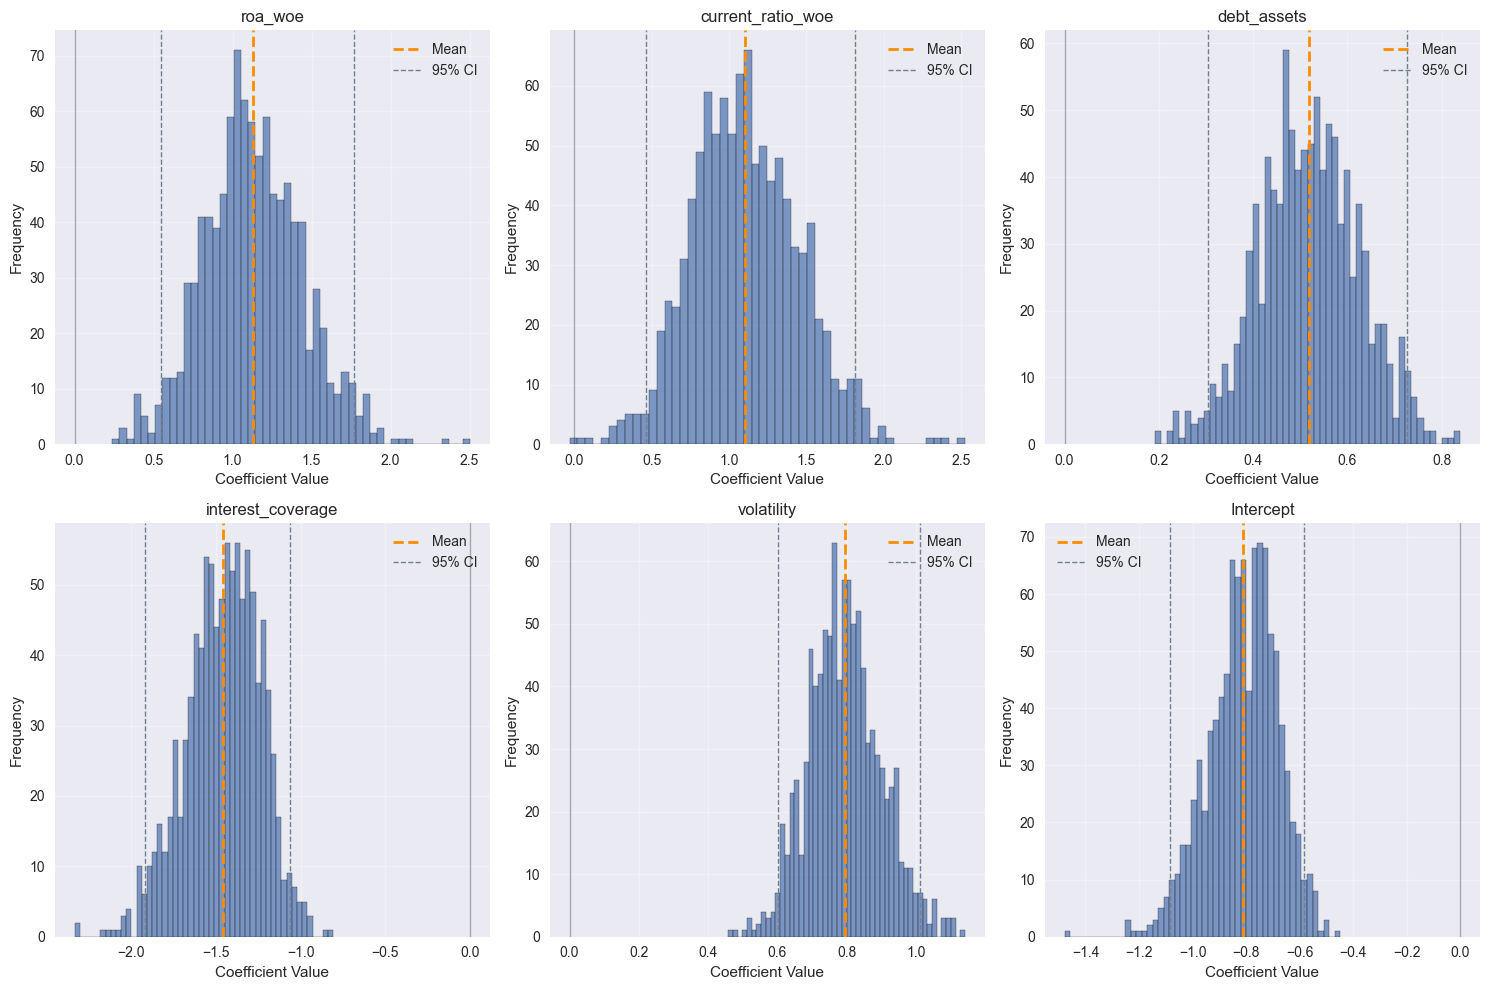

In [677]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (feature, ax) in enumerate(zip(feature_names + ['Intercept'], axes)):
    ax.hist(bootstrap_coeffs[:, i], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(coeff_means[i], color='darkorange', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(coeff_lower[i], color='slategray', linestyle='--', linewidth=1, label='95% CI')
    ax.axvline(coeff_upper[i], color='slategray', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrap_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

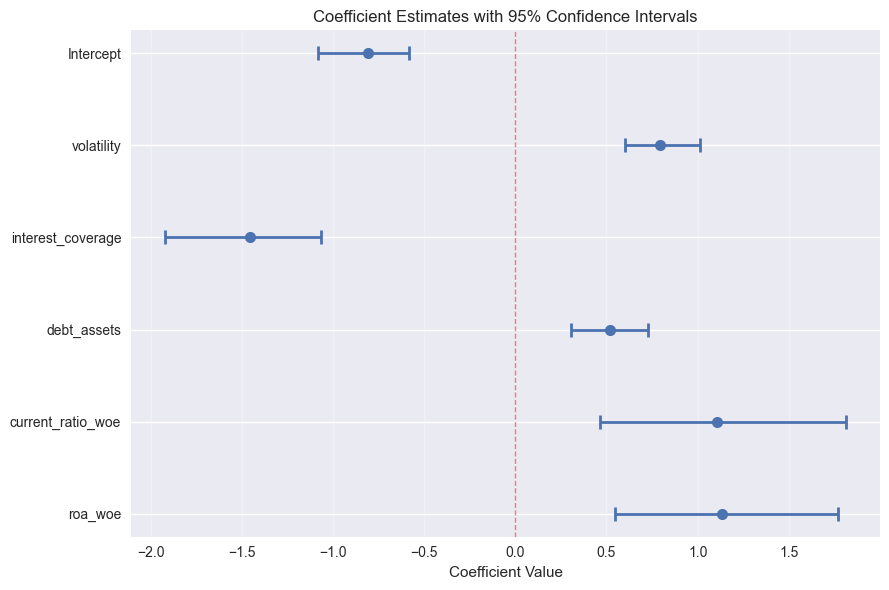

In [660]:
plt.figure(figsize=(9, 6))
y_pos = np.arange(len(feature_names) + 1)

plt.errorbar(coeff_means, y_pos, 
             xerr=[coeff_means - coeff_lower, coeff_upper - coeff_means],
             fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2)
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y_pos, feature_names + ['Intercept'])
plt.xlabel('Coefficient Value')
plt.title('Coefficient Estimates with 95% Confidence Intervals')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('coefficient_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

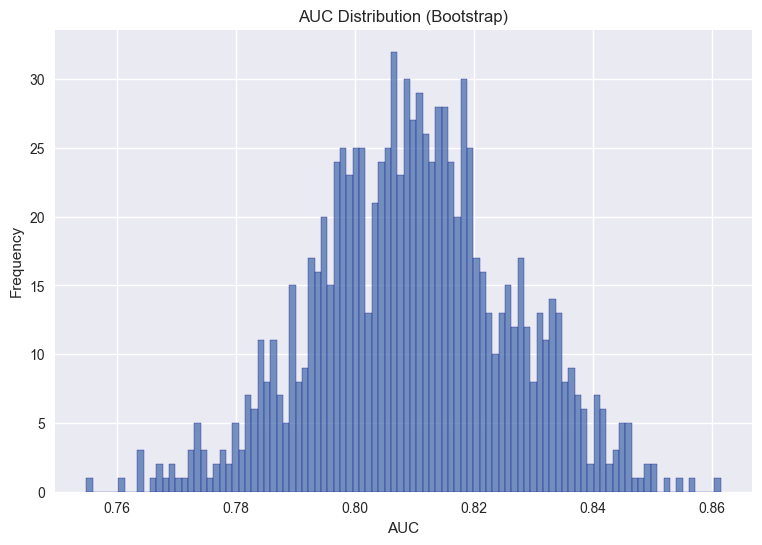

In [695]:
plt.figure(figsize=(9,6))
plt.hist(bootstrap_AUC, bins=100, alpha=0.76, edgecolor='navy')
plt.title("AUC Distribution (Bootstrap)")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']

In [701]:
report_2024 = woe_iv_report(df_2024, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.2084
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0142
                                  WoE        IV
_bin                                           
(122008.167, 2252382.799]    0.110100  0.004676
(2252382.799, 2486126.807]   0.106848  0.000401
(2486126.807, 5503017.955]   0.012766  0.000049
(5503017.955, 78879656.874] -0.181360  0.009082
Initial IV: 1.7031
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging vi

In [703]:
woe_features_2024 = ['roa', 'current_ratio']
original_features_2024 = ['debt_assets', 'interest_coverage', 'volatility']

In [767]:
# report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

In [769]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features_2024),
        ('scaler', StandardScaler(), original_features_2024)
    ],
    remainder='drop' 
)

In [771]:
X_2024 = df_2024[woe_features_2024 + original_features_2024]
y_2024 = df_2024['default']

In [ ]:
# y_pred = best_model.predict(X)
# y_pred_proba = best_model.predict_proba(X)[:, 1]

In [717]:
# y_pred_2024= best_model.predict(X_2024)

In [773]:
y_pred_prob_2024 =  best_model.predict_proba(X_2024)[:, 1]

In [775]:
prob_true, prob_pred = calibration_curve(
    y_2024, y_pred_prob_2024, n_bins=10, strategy='quantile'
)

In [729]:
from sklearn.metrics import brier_score_loss

In [793]:
from sklearn.utils.class_weight import compute_class_weight

In [942]:
from scipy.stats import chi2_contingency

In [1250]:
from scipy import stats

In [1258]:
from scipy.stats import kstest, anderson

In [1330]:
from scipy.stats import rankdata

In [1366]:
from statsmodels.distributions.empirical_distribution import ECDF

In [1434]:
from scipy.special import logit, expit

In [1286]:
from scipy.stats import kendalltau, spearmanr
from scipy.stats import norm, lognorm

In [1573]:
print(df_2024_renew.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead', 'PD_12m', 'ECL_12m', 'rating_band', 'ECL_Rate', 'log_EAD']


In [1086]:
print(df_2024.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead']


In [1088]:
print(len(y_corrected_2024))

3500


In [1092]:
y_corrected_2024.shape

(3500,)

In [1094]:
df_2024_renew = df_2024.copy()

In [1116]:
df_2024_renew['PD_12m'].describe()

count    3.500000e+03
mean     4.222087e-02
std      6.286149e-02
min      3.335571e-20
25%      6.193743e-03
50%      1.951705e-02
75%      5.061777e-02
max      6.555169e-01
Name: PD_12m, dtype: float64

In [1163]:
df_2024_renew.index

Index([3500, 3501, 3502, 3503, 3504, 3505, 3506, 3507, 3508, 3509,
       ...
       6990, 6991, 6992, 6993, 6994, 6995, 6996, 6997, 6998, 6999],
      dtype='int64', length=3500)

In [1754]:
from scipy.stats import gaussian_kde
from scipy.stats import norm